# **0 <font color='orange'>|</font> Install & Import**
---

In [ ]:
# Install


In [1]:
# Import
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

from xgboost import XGBClassifier

from collections import Counter

from imblearn.over_sampling import SMOTE

from yellowbrick.target import class_balance

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="X has feature names, but DecisionTreeClassifier was fitted without feature names")

# **1 <font color='orange'>|</font> Understand**
---

Dies ist ein Glasidentifikationsdatensatz von UCI. Es enthält 10 Attribute einschließlich der ID. Die Antwort ist Glastyp (diskrete 7 Werte)

Attribute Information:

+ RI: refractive index
+ Na: Sodium (unit measurement: weight percent in corresponding oxide, as are + Nattributes 4-10)
+ Mg: Magnesium
+ Al: Aluminum
+ Si: Silicon
+ K: Potassium
+ Ca: Calcium
+ Ba: Barium
+ Fe: Iron


Type of glass: (class attribute)
+ 1 building_windows_float_processed
+ 2 building_windows_non_float_processed
+ 3 vehicle_windows_float_processed
+ 4 vehicle_windows_non_float_processed (none in this database)
+ 5 containers
+ 6 tableware
+ 7 headlamps

[OpenML](https://www.openml.org/search?type=data&status=active&id=43750&sort=runs)

[kaggle](https://www.kaggle.com/datasets/uciml/glass)

In [3]:
data_id = 43750
df = fetch_openml(parser='auto', target_column='default-target', data_id=data_id)

In [21]:
data = df.data.copy()
target = data.pop('Type')

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


In [6]:
counter = Counter(target)
for k,v in counter.items():
    per = v / len(target) * 100
    print('Class=%d, Count=%d, Percentage=%.3f%%' % (k, v, per))

Class=1, Count=70, Percentage=32.710%
Class=2, Count=76, Percentage=35.514%
Class=3, Count=17, Percentage=7.944%
Class=5, Count=13, Percentage=6.075%
Class=6, Count=9, Percentage=4.206%
Class=7, Count=29, Percentage=13.551%


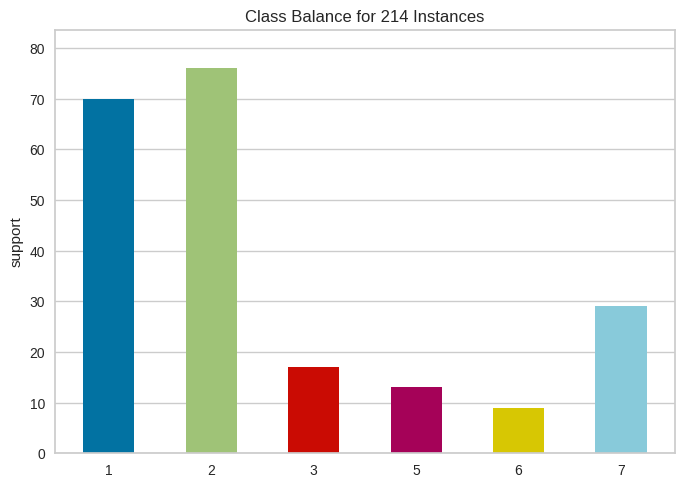

In [26]:
visualizer = class_balance(np.array(target), labels=labels)

# **2 <font color='orange'>|</font> Prepare**
---

In [23]:
labels = [int(i) for i in target.unique()]
target = [int(i) for i in target]
feature_names = data.columns

[1, 2, 3, 5, 6, 7]

In [7]:
# Aufteilen in Trainings- und Testdaten
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.2, random_state=42, stratify=target)

# **3 <font color='orange'>|</font> Model**
---

## **3.1 <font color='orange'>|</font> Ohne Anpassung**
---

In [8]:
# Modell
model = DecisionTreeClassifier(random_state=42)
model.fit(data_train, target_train)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_dt_pure = classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_dt_pure)
print(f1_dt_pure:= f1_score(target_test, target_test_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.79      0.79      0.79        14
           2       0.70      0.47      0.56        15
           3       0.50      0.67      0.57         3
           5       1.00      0.67      0.80         3
           6       0.40      1.00      0.57         2
           7       0.75      1.00      0.86         6

    accuracy                           0.70        43
   macro avg       0.69      0.76      0.69        43
weighted avg       0.73      0.70      0.69        43

0.6930232558139534


In [9]:
# Modell
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(data_train, target_train)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_lr_pure =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_lr_pure)
print(f1_lr_pure:= f1_score(target_test, target_test_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.69      0.64      0.67        14
           2       0.62      0.67      0.65        15
           3       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       0.50      0.50      0.50         2
           7       0.75      1.00      0.86         6

    accuracy                           0.67        43
   macro avg       0.59      0.63      0.61        43
weighted avg       0.64      0.67      0.65        43

0.6547351123495159


## **3.2 <font color='orange'>|</font> SMOTE**
---

In [10]:
# SMOTE anwenden
smote = SMOTE(random_state=42)
data_train_smote, target_train_smote = smote.fit_resample(data_train, target_train)

# Modell trainieren
model = DecisionTreeClassifier(random_state=42)
model.fit(data_train_smote, target_train_smote)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_dt_smote =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_dt_smote)
print(f1_dt_smote:= f1_score(target_test, target_test_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.67      0.57      0.62        14
           2       0.73      0.53      0.62        15
           3       0.22      0.67      0.33         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.65        43
   macro avg       0.71      0.77      0.71        43
weighted avg       0.73      0.65      0.67        43

0.6721092860627744


## **3.3 <font color='orange'>|</font> Gewichte Decision Tree**
---

In [12]:
# Klassen-Gewichte berechnen
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(target_train), y=target_train)
class_weight_dict = {np.unique(target_train)[i]: class_weights[i] for i in range(len(class_weights))}

# Modell trainieren
model = DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42)
model.fit(data_train, target_train)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_dtg =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_dtg)
print(f1_dtg:= f1_score(target_test, target_test_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.83      0.71      0.77        14
           2       0.67      0.53      0.59        15
           3       0.43      1.00      0.60         3
           5       0.50      0.67      0.57         3
           6       0.67      1.00      0.80         2
           7       0.80      0.67      0.73         6

    accuracy                           0.67        43
   macro avg       0.65      0.76      0.68        43
weighted avg       0.71      0.67      0.68        43

0.6775823659544591


## **3.4 <font color='orange'>|</font> Gewichte RandomForest**
---

In [14]:
# Modell trainieren
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(data_train, target_train)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)
report_rf =classification_report(target_test, target_test_pred, labels=labels, zero_division=0.0)
print(report_rf)
print(f1_rf:= f1_score(target_test, target_test_pred, average='weighted'))

              precision    recall  f1-score   support

           1       0.69      0.79      0.73        14
           2       0.77      0.67      0.71        15
           3       0.50      0.33      0.40         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.73      0.77      0.74        43
weighted avg       0.75      0.74      0.74        43

0.739695962951777


## **3.5 <font color='orange'>|</font> Ensemble (xgboost)**
---

In [ ]:
# Modell trainieren

# Label Encoder initialisieren
encoder = LabelEncoder()

# Zielvariablen transformieren
target_train_encoded = encoder.fit_transform(target_train)


model = XGBClassifier(random_state=42)
model.fit(data_train, target_train_encoded)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)

report_xgboost =classification_report(target_test, encoder.inverse_transform(target_test_pred), labels=labels, zero_division=0.0)
print(report_xgboost)
print(f1_xgboost:= f1_score(target_test, encoder.inverse_transform(target_test_pred), average='weighted'))

              precision    recall  f1-score   support

           1       0.79      0.79      0.79        14
           2       0.77      0.67      0.71        15
           3       0.67      0.67      0.67         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       0.83      0.83      0.83         6

    accuracy                           0.77        43
   macro avg       0.75      0.83      0.78        43
weighted avg       0.77      0.77      0.76        43

0.7647840531561462


## **3.6 <font color='orange'>|</font> Kombi xgboost & SMOTE**
---

In [35]:
# Modell trainieren

# Label Encoder initialisieren
encoder = LabelEncoder()

# Zielvariablen transformieren
target_train_encoded = encoder.fit_transform(target_train)

smote = SMOTE(random_state=42)
data_train_smote, target_train_smote = smote.fit_resample(data_train, target_train_encoded)

model = XGBClassifier(random_state=42)
model.fit(data_train_smote, target_train_smote)

# Vorhersagen und Bewertung
target_test_pred = model.predict(data_test)

report_xgboost_plus =classification_report(target_test, encoder.inverse_transform(target_test_pred), labels=labels, zero_division=0.0)
print(report_xgboost_plus)
print(f1_xgboost_plus:= f1_score(target_test, encoder.inverse_transform(target_test_pred), average='weighted'))

0.813084589828776

## **3.7 <font color='orange'>|</font> Zusammenfassung**
---

# **A <font color='orange'>|</font> Appendix**
---

In [15]:
report_rf_dic = classification_report(target_test, target_test_pred, output_dict=True)
# Dict comprehension to extract f1-scores, filtering out non-numeric keys
f1_scores = {key: value['f1-score'] for key, value in report_rf_dic.items() if key.isdigit()}
print(f1_scores)

{'1': 0.7333333333333334, '2': 0.7142857142857142, '3': 0.4, '5': 0.8571428571428571, '6': 0.8, '7': 0.9090909090909091}


In [16]:
values_list = list(f1_scores.values())
sum(values_list)/len(values_list)

0.7356421356421357